In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns


In [2]:
df = pd.read_csv('housing.csv')

print('Forma del dataset:', df.shape)
print('\nColumnas disponibles:')
print(list(df.columns))
print('\nPrimeras filas:')
print(df.head())
print('\nTipos de datos:')
print(df.dtypes)

print(df.isnull().sum())
print()
print(df['ocean_proximity'].value_counts())


Forma del dataset: (20640, 10)

Columnas disponibles:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']

Primeras filas:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR B

In [3]:
X_simple = df[['median_income']]
y = df['median_house_value']

modelo_simple = LinearRegression()
modelo_simple.fit(X_simple, y)

# la pendiente representa el cambio o incremento en la
# varaiable que queremos predecir
print('Pendiente:', round(modelo_simple.coef_[0], 2))
# El intercepto es simplemetne el punto donde
# la recta cruza el eje en Y
print('Intercepto:', round(modelo_simple.intercept_, 2))

ingreso_nuevo = [[8.0]]
prediccion = modelo_simple.predict(ingreso_nuevo)

print(f"Para un ingreso medio de 8.0, el modelo predice: ${prediccion[0]}:,.2f")


Pendiente: 41793.85
Intercepto: 45085.58
Para un ingreso medio de 8.0, el modelo predice: $379436.3703184381:,.2f


/home/chris/data/TALENDIG-ML-SUPERVISADO-MES05/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


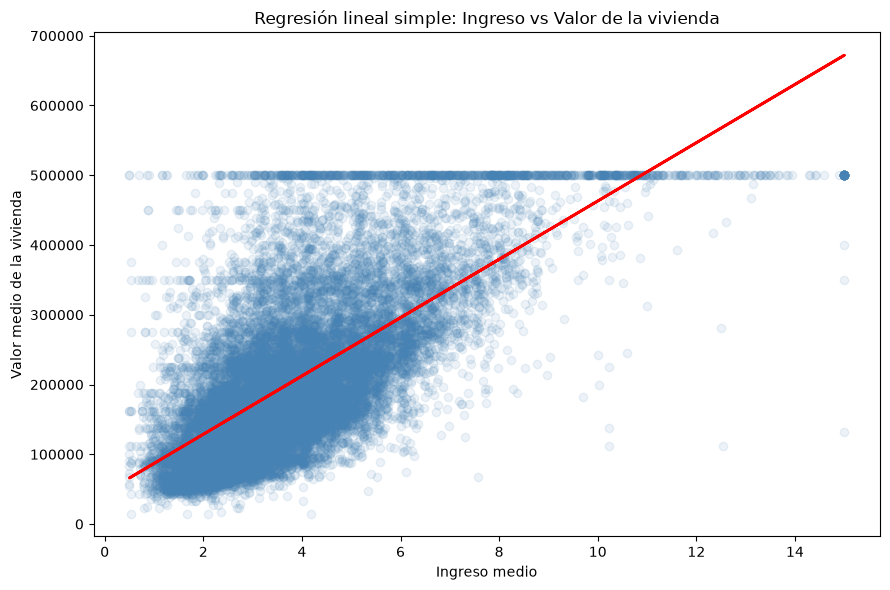

In [4]:
# Visualizacion
plt.figure(figsize=(9, 6))

plt.scatter(
    df['median_income'],
    df['median_house_value'],
    alpha=0.1,
    color='steelblue'
)

plt.plot(
    df['median_income'],
    modelo_simple.predict(X_simple),
    color='red',
    linewidth=2
)

plt.title('Regresión lineal simple: Ingreso vs Valor de la vivienda')
plt.xlabel('Ingreso medio')
plt.ylabel('Valor medio de la vivienda')

plt.tight_layout()
plt.savefig('graficas/01_regresion_simple.png')
plt.show()

